In [1]:
print("hello")

hello


In [2]:
import pandas as pd

# The complete dataset with the exact generated prices
data = {
    'Store Name': ['Pizza Hut', 'PizzaBurg', 'Dominos', 'Pizza Hut', 'Dominos', 'Pizza Hut', 'PizzaRella'],
    'Location': ['Dhanmondi', 'Taltola', 'Dhanmondi', 'Mirpur', 'Mirpur', 'Gulshan', 'taltola'],
    'Price': [651, 311, 637, 626, 363, 387, 375]
}

df = pd.DataFrame(data)
df

,Store Name,Location,Price
0,Pizza Hut,Dhanmondi,651
1,PizzaBurg,Taltola,311
2,Dominos,Dhanmondi,637
3,Pizza Hut,Mirpur,626
4,Dominos,Mirpur,363
5,Pizza Hut,Gulshan,387
6,PizzaRella,taltola,375


dominos er jonno kon outlet ea price ta sobche besi.tkn pandas er maddome kiavev ber korbo?and sob golor jonno oo ber korte chaile kiabe ber korte pari?

In [3]:
dominos_df = df[df['Store Name'] == 'Dominos']
dominos_df

,Store Name,Location,Price
2,Dominos,Dhanmondi,637
4,Dominos,Mirpur,363


এতে শুধু Dominos এর outlet গুলো দেখাবে।

In [4]:
max_price = dominos_df['Price'].max()
max_price

np.int64(637)

In [5]:
dominos_df[dominos_df['Price'] == max_price]

,Store Name,Location,Price
2,Dominos,Dhanmondi,637


সব store এর highest price বের করা

In [6]:
df.groupby('Store Name')['Price'].max()

Store Name
Dominos       637
Pizza Hut     651
PizzaBurg     311
PizzaRella    375
Name: Price, dtype: int64

In [7]:
crr=df.groupby("Store Name").max()

In [8]:
crr

,Location,Price
Store Name,,
Dominos,Mirpur,637
Pizza Hut,Mirpur,651
PizzaBurg,Taltola,311
PizzaRella,taltola,375


In [9]:
crr.mean(numeric_only=True)

Price    493.5
dtype: float64

In [10]:
crr.describe()

,Price
count,4.000000
mean,493.500000
std,175.828515
min,311.000000
25%,359.000000
50%,506.000000
75%,640.500000
max,651.000000


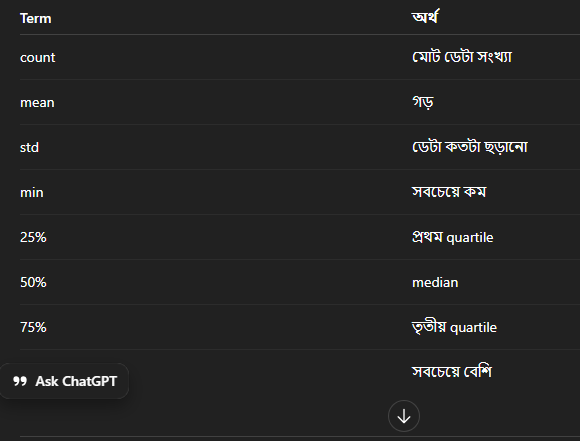

In [11]:
str=df.groupby("Store Name").min()

In [12]:
str

,Location,Price
Store Name,,
Dominos,Dhanmondi,363
Pizza Hut,Dhanmondi,387
PizzaBurg,Taltola,311
PizzaRella,taltola,375


In [13]:
str.mean(numeric_only=True)

Price    359.0
dtype: float64

In [14]:
str.sum(numeric_only=True)

Price    1436
dtype: int64

DESCRIVE METHOD

In [15]:
str.describe()

,Price
count,4.000000
mean,359.000000
std,33.466401
min,311.000000
25%,350.000000
50%,369.000000
75%,378.000000
max,387.000000


so bojte parsi

Pandas মার্জিং/জয়েনিং 

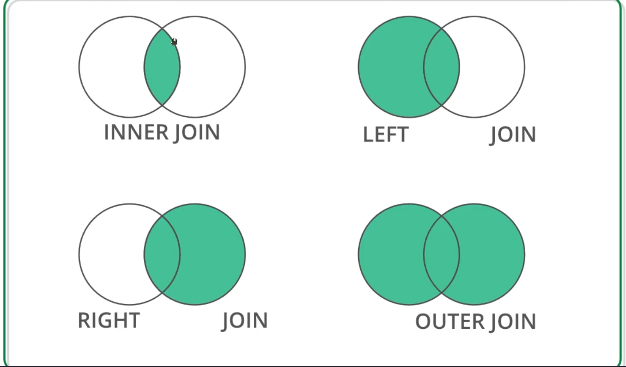

In [16]:
import pandas as pd
import numpy as np

left = pd.DataFrame({
    'key1': ['K0', 'K1', 'K2', 'K3'],
    'A': np.random.randint(1,10,size=4),
    'B': np.random.randint(1,10,size=4)
})

right = pd.DataFrame({
    'key1': ['K0', 'K2', 'K4', 'K5'],
    'C': np.random.randint(1,10,size=4),
    'D': np.random.randint(1,10,size=4)
})

np.random.randint(1,10,size=4)
👉 ১ থেকে ৯ এর মধ্যে ৪টা random সংখ্যা তৈরি করবে

left dataframe এ থাকবে
key1, A, B

right dataframe এ থাকবে
key1, C, D

এই dataset সাধারণত merge / join শেখানোর জন্য ব্যবহার করা হয়।

In [17]:
left

,key1,A,B
0,K0,8,6
1,K1,3,8
2,K2,8,3
3,K3,8,4


In [18]:
right

,key1,C,D
0,K0,9,3
1,K2,1,1
2,K4,9,3
3,K5,6,3


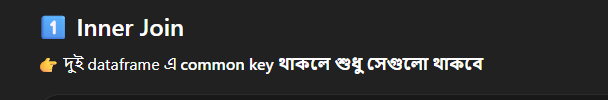

শুধু common key থাকবে (K0, K2) inner merge ea

In [19]:
pd.merge(left, right, on='key1',how="inner")

,key1,A,B,C,D
0,K0,8,6,9,3
1,K2,8,3,1,1


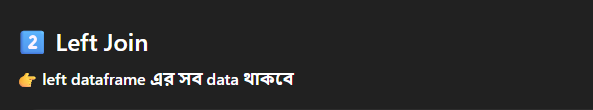

In [20]:
left

,key1,A,B
0,K0,8,6
1,K1,3,8
2,K2,8,3
3,K3,8,4


In [21]:
right

,key1,C,D
0,K0,9,3
1,K2,1,1
2,K4,9,3
3,K5,6,3


Left join মানে হলো left DataFrame এর সব row থাকবে, আর right DataFrame থেকে matching row থাকলে তা যুক্ত হবে, না থাকলে NaN হবে

In [22]:
pd.merge(left, right, on='key1', how='left')

,key1,A,B,C,D
0,K0,8,6,9.0,3.0
1,K1,3,8,NaN,NaN
2,K2,8,3,1.0,1.0
3,K3,8,4,NaN,NaN


Pandas এ Right Join ব্যবহার করা হয় যখন আমরা right dataframe এর সব data রাখতে চাই এবং left dataframe থেকে matching data আনতে চাই।

In [23]:
right_join = pd.merge(left, right, how='right', on='key1')
right_join

,key1,A,B,C,D
0,K0,8.0,6.0,9,3
1,K2,8.0,3.0,1,1
2,K4,NaN,NaN,9,3
3,K5,NaN,NaN,6,3


Outer Join কী করে?

Left dataframe এর সব row রাখে

Right dataframe এর সব row রাখে

যেগুলো match করে না সেখানে NaN দেয়

In [24]:
pd.merge(left, right, how='outer', on='key1')

,key1,A,B,C,D
0,K0,8.0,6.0,9.0,3.0
1,K1,3.0,8.0,NaN,NaN
2,K2,8.0,3.0,1.0,1.0
3,K3,8.0,4.0,NaN,NaN
4,K4,NaN,NaN,9.0,3.0
5,K5,NaN,NaN,6.0,3.0


col1 → 1 থেকে 9 পর্যন্ত random সংখ্যা
col2 → 100 থেকে 499 পর্যন্ত random সংখ্যা
col3 → list থেকে random নাম (steve, bob, mike, sara)

In [27]:
import pandas as pd
df=pd.DataFrame({
    "col1":np.random.randint(1,10,size=10),
    "col2":np.random.randint(100,500,size=10),
    "col3":np.random.choice(["steve","bob","mike","sara"],size=10)
})
df

,col1,col2,col3
0,5,456,mike
1,7,119,bob
2,6,207,sara
3,9,161,steve
4,6,461,sara
5,8,213,bob
6,6,310,mike
7,5,264,mike
8,9,324,mike
9,5,468,steve


NumPy-তে:

randint() → number generate করে
choice() → list থেকে random select করে

In [28]:
df.head()

,col1,col2,col3
0,5,456,mike
1,7,119,bob
2,6,207,sara
3,9,161,steve
4,6,461,sara


In [29]:
df.tail()

,col1,col2,col3
5,8,213,bob
6,6,310,mike
7,5,264,mike
8,9,324,mike
9,5,468,steve


In [33]:
df.head(10)

,col1,col2,col3
0,5,456,mike
1,7,119,bob
2,6,207,sara
3,9,161,steve
4,6,461,sara
5,8,213,bob
6,6,310,mike
7,5,264,mike
8,9,324,mike
9,5,468,steve


col 3 te kotofolo unique nam ase 

In [34]:
df["col3"].unique()

<StringArray>
['mike', 'bob', 'sara', 'steve']
Length: 4, dtype: str

In [35]:
df["col3"].value_counts()

col3
mike     4
bob      2
sara     2
steve    2
Name: count, dtype: int64

In [36]:
 df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   col1    10 non-null     int32
 1   col2    10 non-null     int32
 2   col3    10 non-null     str  
dtypes: int32(2), str(1)
memory usage: 292.0 bytes


📊 df.info() কী?

👉 df.info() হলো Pandas-এর একটা function, যা DataFrame-এর summary information দেখায়।

🔹 কী কী দেখায়?

df.info() run করলে তুমি পাবা:

মোট কয়টা row (entries)
column-এর নাম
প্রতিটা column-এর data type
non-null (missing value আছে কিনা)
memory usage

In [39]:
df.sort_values(by="col2")

,col1,col2,col3
1,7,119,bob
3,9,161,steve
2,6,207,sara
5,8,213,bob
7,5,264,mike
6,6,310,mike
8,9,324,mike
0,5,456,mike
4,6,461,sara
9,5,468,steve



🧩 Pandas apply() method কী?

👉 apply() হলো একটা powerful function, যেটা দিয়ে তুমি custom function ব্যবহার করে DataFrame বা Series-এর উপর operation চালাতে পারো।


In [43]:
def times3(x):

    return x*3

In [44]:
df["col2"].apply(times3)

0    1368
1     357
2     621
3     483
4    1383
5     639
6     930
7     792
8     972
9    1404
Name: col2, dtype: int64

In [45]:
df["col3"].apply(len)

0    4
1    3
2    4
3    5
4    4
5    3
6    4
7    4
8    4
9    5
Name: col3, dtype: int64

In [46]:
df.to_csv("test.csv")

In [48]:
pd.read_csv("test.csv", index_col=0)

,col1,col2,col3
0,5,456,mike
1,7,119,bob
2,6,207,sara
3,9,161,steve
4,6,461,sara
5,8,213,bob
6,6,310,mike
7,5,264,mike
8,9,324,mike
9,5,468,steve
